<img src="assets/belieflens-notebook-header.png" alt="BeliefLens — Measure belief. Govern uncertainty." width="760"/>

# BeliefLens SPY/SGOV frozen public reproduction

## Goal

Understand how BeliefLens turns prompt-dependent language probabilities into calibrated probabilities over three meaningful market states—**Risk-on**, **Mixed**, and **Risk-off**—and how the quality of that measurement is tested before it is used downstream.

## What you will see

1. The evidence and state definitions used by the benchmark.
2. The frozen semantic and calibration maps.
3. Recovery, coverage, prompt-stability and token-attribution diagnostics.
4. Calibrated state probabilities for each observation.
5. A static long-horizon transport comparison.
6. A separate weekly point-in-time walk-forward calibration and SPY/SGOV illustration.

The principal output is a calibrated probability distribution over declared states with an audit trail—not a generated trading recommendation. Code inputs are hidden by default; click a cell's disclosure control to inspect them. Outputs remain visible.

The demonstration is keyless and non-configurable. It attempts one BeliefLens request, performs no model inference, and incurs no provider cost. If the public route is unavailable, it loads the archived copy of the same API response. The bundle beside this notebook supplies the frozen source records used for transparent inspection. For experiments using your own evidence and model, use the separate authenticated notebook in this directory.

**Further information:** [BeliefLens primer](https://belieflens.org/#/primer) · [Finance applications](https://belieflens.org/#/finance) · [Software and integration guide](https://belieflens.org/#/software)


In [1]:
from pathlib import Path
from io import BytesIO
import atexit, json, os, subprocess, sys, time, uuid, zipfile
import httpx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')
BELIEFLENS_URL = os.getenv('BELIEFLENS_URL', 'https://demo.belieflens.org')
bundle_suffix = Path('outputs/belieflens-current-state-spy-sgov-v4/offline_reproduction')
candidates = [Path.cwd()/bundle_suffix, Path.cwd()/'engine'/bundle_suffix, Path.cwd()/'examples/notebooks/finance/data/offline_reproduction', Path.cwd()/'data/offline_reproduction', Path.cwd().parents[1]/bundle_suffix]
BUNDLE = next((path.resolve() for path in candidates if path.exists()), candidates[0])
assert BUNDLE.exists(), f'Frozen bundle not found: {BUNDLE}'
BUNDLE


PosixPath('/private/tmp/belieflens-repro-strategy/examples/notebooks/finance/data/offline_reproduction')

## 1. Load the immutable public demonstration

We first load the already frozen result. This separates inspection from experimentation: rerunning the notebook cannot silently change the model, calibration or reported evidence. The visible output confirms whether the hosted or archived source was used and whether its integrity checks passed.


In [2]:
def load_public_demo():
    url = BELIEFLENS_URL.rstrip('/') + '/v1/examples/SPY-trading'
    try:
        response = httpx.get(url, timeout=15, follow_redirects=False)
        response.raise_for_status()
        result = response.json()
        result['_reproduction_source'] = 'live immutable endpoint'
        return result
    except (httpx.HTTPError, json.JSONDecodeError):
        archived = json.loads((BUNDLE/'API_REPRODUCTION_RESULT.json').read_text())
        archived['_reproduction_source'] = 'archived immutable API response'
        return archived

result = load_public_demo()

pd.Series({
    'source': result['_reproduction_source'],
    'endpoint': result['endpoint'],
    'reproduction passed': result['reproduction_passed'],
    'provider API calls': result['provider_api_calls'],
    'demo mode': result.get('demo_mode', 'immutable'),
    'configurable': result.get('configurable', False),
    'map maximum error': result['frozen_semantic_map_max_abs_error'],
    'diagnostic maximum error': result['diagnostic_max_abs_error'],
    'portfolio maximum error': result['portfolio_metric_max_abs_error'],
}, name='API reproduction')


source                      archived immutable API response
endpoint                           /v1/examples/SPY-trading
reproduction passed                                    True
provider API calls                                        0
demo mode                                         immutable
configurable                                          False
map maximum error                                       0.0
diagnostic maximum error                                0.0
portfolio maximum error                                 0.0
Name: API reproduction, dtype: object

## 2. Input evidence and benchmark design
Here we inspect what the model was allowed to know and what it was asked to measure. Each record contains point-in-time market evidence and a reviewed reference state. The reference responses support calibration and evaluation; future returns are excluded from the language measurement and appear only in the later portfolio illustration.


In [3]:
records = pd.DataFrame(json.loads(line) for line in (BUNDLE/'inputs/records.jsonl').read_text().splitlines() if line.strip())
records[['observation_id', 'decision_date', 'partition', 'reference_state', 'evidence_text']].head(5)


,observation_id,decision_date,partition,reference_state,evidence_text
0,daily-2018-01-10,2018-01-10,calibration,Risk-on,"As of 2018-01-10, SPY returned +1.3% over five trading days and +4.0% over twenty. Trailing twen..."
1,daily-2018-01-29,2018-01-29,calibration,Risk-on,"As of 2018-01-29, SPY returned +0.7% over five trading days and +6.3% over twenty. Trailing twen..."
2,daily-2018-02-09,2018-02-09,calibration,Risk-off,"As of 2018-02-09, SPY returned -5.0% over five trading days and -5.2% over twenty. Trailing twen..."
3,daily-2018-02-12,2018-02-12,calibration,Risk-off,"As of 2018-02-12, SPY returned +0.5% over five trading days and -4.5% over twenty. Trailing twen..."
4,daily-2018-03-05,2018-03-05,calibration,Risk-off,"As of 2018-03-05, SPY returned -2.1% over five trading days and -1.2% over twenty. Trailing twen..."


In [4]:
benchmark_counts = pd.crosstab(records['partition'], records['reference_state']).reindex(
    ['calibration', 'prompt_validation', 'conformal', 'test'], fill_value=0
)
benchmark_counts['Total'] = benchmark_counts.sum(axis=1)
benchmark_counts.loc['Total'] = benchmark_counts.sum(axis=0)
benchmark_counts


reference_state,Mixed,Risk-off,Risk-on,Total
partition,,,,
calibration,60,60,60,180
prompt_validation,15,15,15,45
conformal,20,20,20,60
test,22,67,38,127
Total,117,162,133,412


### Strictly chronological partitions

The benchmark uses time-ordered—not randomly intermingled—partitions:

- **Calibration:** January 2018–December 2020
- **Prompt validation:** January 2021–December 2022
- **Conformal calibration:** January 2023–December 2024
- **Untouched test/backtest:** January 2–July 7, 2026

Consequently, the semantic calibration map, prompt choice and conformal uncertainty rule were fixed using observations dated before the 2026 evaluation period. The 2026 records were not used to fit the measurement channel.


## 3. Frozen semantic map and calibration diagnostics

The raw model quantities are probabilities assigned to controlled response tokens or phrases. The semantic map groups those responses into the declared market states. A calibrator fitted on the frozen calibration partition then maps the raw state vector to an estimated reference posterior. The output below reports whether this inverse measurement is identifiable, how well it recovers held-out reference probabilities, and whether its uncertainty sets attain their target coverage.


In [5]:
semantic_map = json.loads((BUNDLE/'semantic_map.json').read_text())
pd.Series({
    'states': ', '.join(semantic_map['states']),
    'input candidates': ', '.join(semantic_map['input_candidates']),
    'transform': semantic_map['input_transform'],
    'calibration observations': len(semantic_map['calibration_scenario_ids']),
    'estimator': semantic_map['model_type'],
    'ridge C': semantic_map['regularization_C'],
}, name='Calibrated semantic map')


states                                     Risk-on, Mixed, Risk-off
input candidates                   Risk-on, Mixed, Risk-off, Unsure
transform                         additive log ratio against Unsure
calibration observations                                        180
estimator                   sklearn.linear_model.LogisticRegression
ridge C                                                         1.0
Name: Calibrated semantic map, dtype: object

In [6]:
d = result['measurement_diagnostics']
diagnostic_table = pd.DataFrame([
    ('Held-out accuracy', d['held_out_recovery']['accuracy'], 'higher is better'),
    ('Held-out log loss', d['held_out_recovery']['log_loss'], 'lower is better'),
    ('Held-out Brier score', d['held_out_recovery']['multiclass_brier'], 'lower is better'),
    ('Mean JS posterior error', d['held_out_recovery']['mean_js_error'], 'lower is better'),
    ('Conformal coverage', d['conformal_coverage']['empirical'], f"nominal = {d['conformal_coverage']['nominal']:.0%}"),
    ('Prompt perturbation JS', d['prompt_stability']['mean_js'], 'lower is more stable'),
    ('Normalized state entropy', d['uncertainty']['mean_normalized_state_entropy'], 'state uncertainty'),
    ('Observed candidate mass', d['uncertainty']['mean_observed_candidate_mass'], 'higher is better'),
    ('Lexical–elicited JS', d['elicited_discrepancy']['mean_js_lexical_vs_elicited'], 'channel disagreement'),
], columns=['Diagnostic', 'Value', 'Interpretation'])
diagnostic_table.style.format({'Value': '{:.4f}'})


,Diagnostic,Value,Interpretation
0,Held-out accuracy,0.3780,higher is better
1,Held-out log loss,0.7680,lower is better
2,Held-out Brier score,0.4883,lower is better
3,Mean JS posterior error,0.2217,lower is better
4,Conformal coverage,0.8898,nominal = 90%
5,Prompt perturbation JS,0.0156,lower is more stable
6,Normalized state entropy,0.7239,state uncertainty
7,Observed candidate mass,0.9990,higher is better
8,Lexical–elicited JS,0.0513,channel disagreement


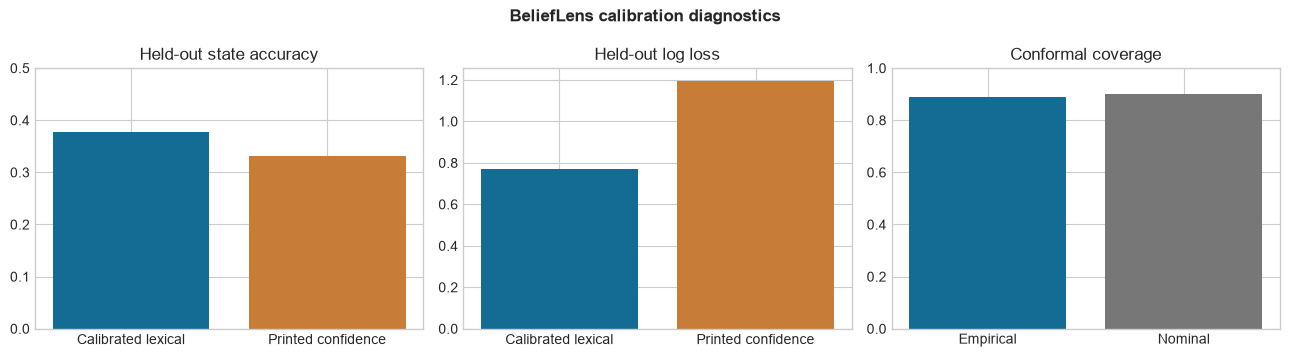

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
recovery = d['held_out_recovery']; printed = d['printed_probability_recovery']
axes[0].bar(['Calibrated lexical', 'Printed confidence'], [recovery['accuracy'], printed['accuracy']], color=['#146c94', '#c77d38'])
axes[0].set_title('Held-out state accuracy'); axes[0].set_ylim(0, .5)
axes[1].bar(['Calibrated lexical', 'Printed confidence'], [recovery['log_loss'], printed['log_loss']], color=['#146c94', '#c77d38'])
axes[1].set_title('Held-out log loss')
axes[2].bar(['Empirical', 'Nominal'], [d['conformal_coverage']['empirical'], d['conformal_coverage']['nominal']], color=['#146c94', '#777777'])
axes[2].set_title('Conformal coverage'); axes[2].set_ylim(0, 1)
fig.suptitle('BeliefLens calibration diagnostics', fontweight='bold'); fig.tight_layout()


## 4. Attribute uncertainty and recovery difficulty

The frozen attribution endpoint separates two user-facing questions: sensitivity to information-equivalent prompt presentation and the contribution of each declared semantic state to uncertainty and held-out recovery error. These are auditable local sensitivity diagnostics—not claims that a word in the evidence is the model's universal internal cause of error. The analysis uses stored responses and makes no provider calls.

BeliefLens may use an internal response encoding to control phrase-length and tokenization differences, but that implementation detail is mapped back to the declared states before reporting. The tables therefore describe Risk-on, Mixed, Risk-off and Unsure directly. They do not purport to rank the words in a financial article that caused uncertainty; that would require a separate, prespecified evidence-span perturbation experiment.


In [8]:
def load_public_attributions():
    url = BELIEFLENS_URL.rstrip('/') + '/v1/examples/SPY-trading/attributions'
    try:
        response = httpx.get(url, timeout=20)
        response.raise_for_status()
        return response.json(), 'hosted frozen endpoint'
    except Exception as exc:
        archived = BUNDLE/'attribution_result.json'
        if not archived.exists(): raise RuntimeError(f'Hosted attribution unavailable and no archive found: {exc}') from exc
        return json.loads(archived.read_text()), 'archived frozen response'

attribution, attribution_source = load_public_attributions()
pd.Series({
    'source': attribution_source,
    'records analyzed': attribution['records_analyzed'],
    'provider API calls': attribution['provider_api_calls'],
    'prompt configurations ranked': len(attribution['rankings']['prompt_spans']),
    'semantic states ranked': len(attribution['rankings']['output_candidates']),
    'semantic top-k states ranked': sum(x.get('semantic_state') is not None for x in attribution['rankings']['top_k_tokens']),
}, name='Attribution audit')


source                          archived frozen response
records analyzed                                     412
provider API calls                                     0
prompt configurations ranked                           2
semantic states ranked                                 4
semantic top-k states ranked                           3
Name: Attribution audit, dtype: object

In [9]:
prompt_attribution = pd.DataFrame(attribution['rankings']['prompt_spans'])
output_attribution = pd.DataFrame(attribution['rankings']['output_candidates'])
mapping = attribution.get('verbalizer_mapping', {})
output_attribution['semantic_state'] = output_attribution['candidate'].map(mapping).fillna(output_attribution['candidate'])
semantic_output = output_attribution.drop(columns=['candidate'], errors='ignore')
recovery_by_state = semantic_output[[
    'semantic_state', 'records', 'mean_entropy_contribution',
    'mean_absolute_local_brier_sensitivity'
]].sort_values('mean_absolute_local_brier_sensitivity', ascending=False).reset_index(drop=True)
recovery_by_state.insert(0, 'recovery_rank', np.arange(1, len(recovery_by_state) + 1))

record_recovery = pd.DataFrame([
    {
        'source_id': record['source_id'],
        'reference_state': record['reference_state'],
        'semantic_state': mapping.get(item['candidate'], item['candidate']),
        'probability': item['probability'],
        'entropy_share': item['entropy_share'],
        'local_brier_sensitivity': item['local_brier_sensitivity'],
        'absolute_local_brier_sensitivity': abs(item['local_brier_sensitivity']),
    }
    for record in attribution['records']
    for item in record['output_candidate_attributions']
]).sort_values('absolute_local_brier_sensitivity', ascending=False).head(12).reset_index(drop=True)
record_recovery.insert(0, 'rank', np.arange(1, len(record_recovery) + 1))

print('Prompt transformations ranked by semantic instability')
display(prompt_attribution)
print('Semantic candidates ranked by posterior-recovery difficulty')
display(recovery_by_state.style.format({
    'mean_entropy_contribution': '{:.5f}',
    'mean_absolute_local_brier_sensitivity': '{:.5f}',
}))
print('Largest record-level recovery sensitivities')
display(record_recovery.style.format({
    'probability': '{:.4f}', 'entropy_share': '{:.1%}',
    'local_brier_sensitivity': '{:+.5f}',
    'absolute_local_brier_sensitivity': '{:.5f}',
}))


Prompt transformations ranked by semantic instability


,role,text,tokens,records,mean_js_instability,mean_brier_attribution,mean_absolute_brier_attribution
0,prompt presentation,reordered state presentation,"[reordered, state, presentation]",172,0.021908,-0.029930,0.097539
1,prompt presentation,evidence-first ordering,"[evidence-first, ordering]",172,0.016415,-0.001147,0.063619


Semantic candidates ranked by posterior-recovery difficulty


,recovery_rank,semantic_state,records,mean_entropy_contribution,mean_absolute_local_brier_sensitivity
0,1,Risk-off,412,0.01425,0.05247
1,2,Risk-on,412,0.01322,0.04312
2,3,Mixed,412,0.02943,0.03670
3,4,Unsure,412,0.00000,0.01825


Largest record-level recovery sensitivities


,rank,source_id,reference_state,semantic_state,probability,entropy_share,local_brier_sensitivity,absolute_local_brier_sensitivity
0,1,daily-2026-06-02,Risk-on,Mixed,0.0293,78.2%,+0.03712,0.03712
1,2,daily-2026-04-17,Risk-on,Mixed,0.0474,75.8%,+0.03694,0.03694
2,3,daily-2020-10-23,Risk-on,Mixed,0.0474,75.8%,+0.03694,0.03694
3,4,daily-2021-11-09,Risk-on,Mixed,0.1192,69.4%,+0.03651,0.03651
4,5,daily-2018-08-07,Mixed,Mixed,0.0000,32.2%,-0.03570,0.03570
5,6,daily-2019-02-12,Risk-on,Mixed,0.6225,44.5%,+0.03546,0.03546
6,7,daily-2020-07-30,Risk-on,Mixed,0.9241,27.1%,+0.03490,0.03490
7,8,daily-2021-04-16,Risk-on,Mixed,0.9241,27.1%,+0.03490,0.03490
8,9,daily-2026-06-02,Risk-on,Risk-off,0.0000,0.0%,-0.02502,0.02502
9,10,daily-2026-04-17,Risk-on,Risk-off,0.0000,0.0%,-0.02489,0.02489


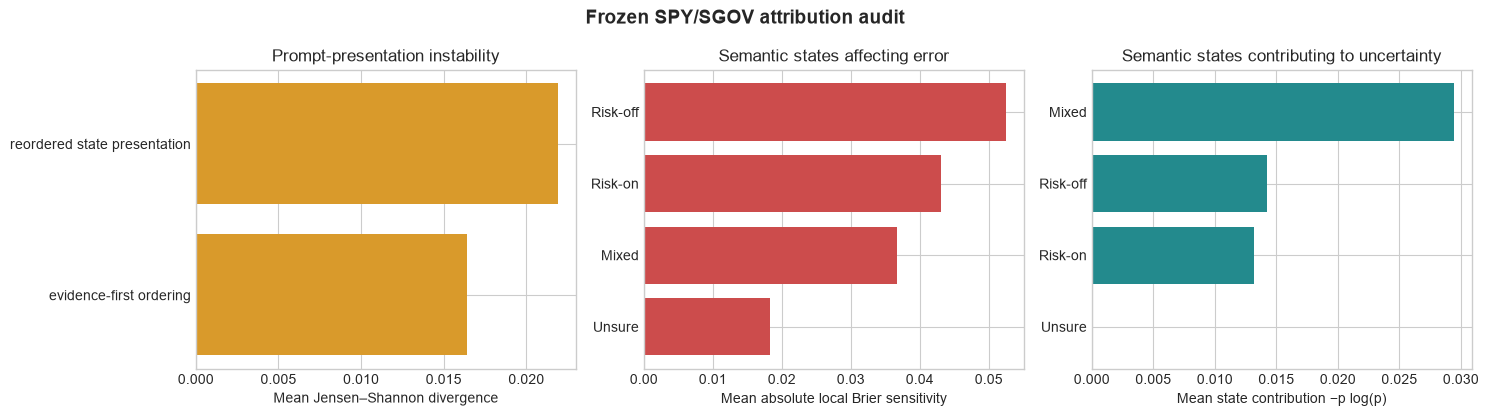

In [10]:
import matplotlib.pyplot as plt

def visualize_attributions(attribution, *, title='BeliefLens uncertainty attribution'):
    prompt = pd.DataFrame(attribution['rankings']['prompt_spans']).head(8)
    output = pd.DataFrame(attribution['rankings']['output_candidates']).head(8)
    mapping = attribution.get('verbalizer_mapping', {})
    if len(output):
        output['semantic_state'] = output['candidate'].map(mapping).fillna(output['candidate'])
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

    if len(prompt):
        axes[0].barh(prompt['text'][::-1], prompt['mean_js_instability'][::-1], color='#d99a2b')
    axes[0].set_title('Prompt-presentation instability')
    axes[0].set_xlabel('Mean Jensen–Shannon divergence')

    if len(output):
        axes[1].barh(output['semantic_state'][::-1], output['mean_absolute_local_brier_sensitivity'][::-1], color='#cc4c4c')
    axes[1].set_title('Semantic states affecting error')
    axes[1].set_xlabel('Mean absolute local Brier sensitivity')

    if len(output):
        ranked_entropy = output.sort_values('mean_entropy_contribution', ascending=True)
        axes[2].barh(ranked_entropy['semantic_state'], ranked_entropy['mean_entropy_contribution'], color='#238a8d')
    axes[2].set_title('Semantic states contributing to uncertainty')
    axes[2].set_xlabel('Mean state contribution −p log(p)')

    fig.suptitle(title, fontsize=14, fontweight='bold')
    fig.tight_layout()
    return fig, axes
visualize_attributions(attribution, title='Frozen SPY/SGOV attribution audit');


## 5. Calibrated state measurements

Each row now contains the principal statistical output: a calibrated probability vector over Risk-on, Mixed and Risk-off. The modal state is a summary only; downstream users should retain the complete vector, its uncertainty information and the associated diagnostic status.


In [11]:
rows = pd.read_csv(BUNDLE/'row_level_measurements.csv')
rows['SPY_weight'] = rows['calibrated_risk_on'] + 0.5 * rows['calibrated_mixed']
decision_columns = ['date', 'partition', 'external_regime', 'raw_risk_on', 'raw_mixed', 'raw_risk_off', 'raw_unsure',
                    'calibrated_risk_on', 'calibrated_mixed', 'calibrated_risk_off', 'SPY_weight',
                    'portfolio_spy_return', 'portfolio_safe_return']
rows.loc[rows.partition == 'test', decision_columns].head(8).style.format({column: '{:.4f}' for column in decision_columns if column not in {'date', 'partition', 'external_regime'}})


,date,partition,external_regime,raw_risk_on,raw_mixed,raw_risk_off,raw_unsure,calibrated_risk_on,calibrated_mixed,calibrated_risk_off,SPY_weight,portfolio_spy_return,portfolio_safe_return
285,2026-01-02,test,Mixed,0.9047,0.0953,0.0000,0.0000,0.2664,0.7329,0.0007,0.6328,0.0067,0.0001
286,2026-01-05,test,Mixed,1.0000,0.0000,0.0000,0.0000,0.6308,0.3454,0.0238,0.8035,0.0059,0.0001
287,2026-01-06,test,Risk-on,1.0000,0.0000,0.0000,0.0000,0.6308,0.3454,0.0238,0.8035,-0.0032,0.0001
288,2026-01-07,test,Risk-on,1.0000,0.0000,0.0000,0.0000,0.6308,0.3454,0.0238,0.8035,-0.0001,0.0001
289,2026-01-08,test,Mixed,1.0000,0.0000,0.0000,0.0000,0.6308,0.3454,0.0238,0.8035,0.0066,0.0002
290,2026-01-09,test,Risk-on,1.0000,0.0000,0.0000,0.0000,0.6308,0.3454,0.0238,0.8035,0.0016,0.0002
291,2026-01-12,test,Risk-on,1.0000,0.0000,0.0000,0.0000,0.6308,0.3454,0.0238,0.8035,-0.0020,0.0001
292,2026-01-13,test,Risk-on,1.0000,0.0000,0.0000,0.0000,0.6308,0.3454,0.0238,0.8035,-0.0049,0.0001


## 6. Recent rolling SPY/SGOV evaluation

This deployment study removes the stale-calibration concern by constructing a new measurement channel from 2025 observations. The initial blocks are **January–June 2025 calibration (122 trading sessions)**, **July–September prompt validation (64)** and **October–December conformal calibration (64)**. At the first decision in each 2026 trading week, all three boundaries advance together: the newest eligible sessions enter the conformal block and the oldest sessions leave calibration. Every 250-session window ends before its deployment date.

The fitted language model is frozen before the 2026 evaluation period. Stored observations are reused here, so this notebook makes no provider request. Because the provider's top alternatives did not expose every candidate on every record, the estimator uses the observable candidate probabilities together with missingness indicators and the reported residual-mass bound. It does **not** silently treat an unreturned candidate as having known zero probability.

### What exactly is the trading strategy?

BeliefLens estimates the **current** market-stress probabilities

$$
(p_{\mathrm{on},t},p_{\mathrm{mixed},t},p_{\mathrm{off},t}).
$$

These are measurements of a contemporaneous state—not direct return forecasts. For this secondary portfolio illustration, a simple rule translates the complete probability vector into a long-only, fully invested allocation:

$$
w^{\mathrm{SPY}}_t=p_{\mathrm{on},t}+\tfrac12p_{\mathrm{mixed},t},
\qquad
w^{\mathrm{SGOV}}_t=1-w^{\mathrm{SPY}}_t.
$$

Thus a pure Risk-on state holds 100% SPY; a pure Mixed state holds 50% SPY and 50% SGOV; and a pure Risk-off state holds 100% SGOV. Intermediate probabilities produce intermediate weights. For example, probabilities (0.60, 0.30, 0.10) imply **75% SPY and 25% SGOV**. The allocation is recomputed each trading day using information available by that decision date and earns the following trading session's total returns. Rebalancing costs five basis points times the absolute change in SPY weight. There is no leverage, short position or return-prediction model hidden in the rule.

The main comparison is against SPY, SGOV, fixed 50/50 SPY–SGOV and a conventional 10% volatility-controlled allocation. A separately declared uncertainty-controlled variant shrinks the BeliefLens weight toward 50/50 as normalized semantic entropy rises or the conformal prediction set widens; it is reported as an additional diagnostic and was not substituted for the primary rule after observing performance.


,Diagnostic,Value,Interpretation
0,Out-of-sample decisions,127.000,2026 only
1,Weekly calibration vintages,28.000,all fitted on earlier observations
2,State-recovery accuracy,0.646,higher is better
3,Multiclass log loss,0.648,lower is better
4,Conformal coverage,0.890,nominal level: 90%
5,Mean prediction-set size,1.409,out of three states
6,Mean unobserved-mass bound,0.001,top-k coarsening diagnostic


,Annualized return,Annualized volatility,Excess Sharpe vs SGOV,Maximum drawdown,Annualized turnover
Strategy,,,,,
BeliefLens linear state allocation,13.0%,6.7%,1.32,2.7%,10.8x
BeliefLens uncertainty-controlled,10.3%,6.6%,0.97,4.1%,5.2x
SPY buy-and-hold,20.1%,14.1%,1.12,8.9%,0.0x
SGOV buy-and-hold,3.7%,0.2%,—,0.0%,0.0x
Fixed 50/50 SPY-SGOV,11.9%,7.0%,1.12,4.2%,0.0x
Conventional 10% volatility control,9.8%,11.0%,0.57,7.3%,5.9x


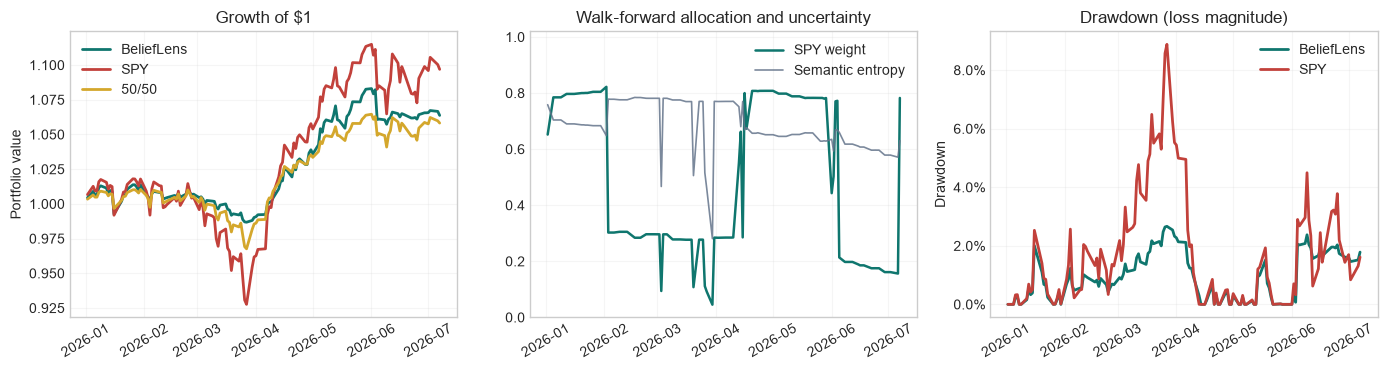

,deployment_date,window_start,window_end,selected_C,conformal_threshold
22,2026-06-01,2025-06-02,2026-05-29,1.0,0.561495
23,2026-06-08,2025-06-09,2026-06-05,10.0,0.579055
24,2026-06-15,2025-06-16,2026-06-12,10.0,0.587623
25,2026-06-22,2025-06-23,2026-06-18,10.0,0.587630
26,2026-06-29,2025-06-30,2026-06-26,10.0,0.581737
27,2026-07-06,2025-07-07,2026-07-02,10.0,0.569416


In [12]:
from IPython.display import display

RV5 = BUNDLE.parent/'derived'/'rolling_v5'
channel_result = json.loads((RV5/'ROLLING_CHANNEL_RESULTS.json').read_text())
portfolio_result = json.loads((RV5/'ROLLING_PORTFOLIO_RESULTS.json').read_text())
fit_audit = pd.DataFrame(json.loads((RV5/'rolling_fit_audit.json').read_text()))
rolling = pd.read_csv(RV5/'rolling_portfolio_backtest.csv', parse_dates=['date'])

measurement_table = pd.DataFrame([
    ('Out-of-sample decisions', channel_result['test_records'], '2026 only'),
    ('Weekly calibration vintages', channel_result['weekly_refits'], 'all fitted on earlier observations'),
    ('State-recovery accuracy', channel_result['accuracy'], 'higher is better'),
    ('Multiclass log loss', channel_result['log_loss'], 'lower is better'),
    ('Conformal coverage', channel_result['conformal_coverage'], 'nominal level: 90%'),
    ('Mean prediction-set size', channel_result['mean_prediction_set_size'], 'out of three states'),
    ('Mean unobserved-mass bound', channel_result['mean_unobserved_mass_lower_bound'], 'top-k coarsening diagnostic'),
], columns=['Diagnostic', 'Value', 'Interpretation'])
display(measurement_table.style.format({'Value': lambda x: f'{x:.3f}' if isinstance(x, float) else str(x)}))

metric_rows = []
for strategy, values in portfolio_result['metrics'].items():
    metric_rows.append({
        'Strategy': strategy,
        'Annualized return': values['annualized_return'],
        'Annualized volatility': values['annualized_volatility'],
        'Excess Sharpe vs SGOV': values['excess_sharpe_vs_sgov'],
        'Maximum drawdown': values['maximum_drawdown_loss_magnitude'],
        'Annualized turnover': values['annualized_turnover'],
    })
portfolio_table = pd.DataFrame(metric_rows).set_index('Strategy')
display(portfolio_table.style.format({
    'Annualized return': '{:.1%}', 'Annualized volatility': '{:.1%}',
    'Excess Sharpe vs SGOV': lambda x: '—' if pd.isna(x) else f'{x:.2f}',
    'Maximum drawdown': '{:.1%}', 'Annualized turnover': '{:.1f}x',
}))

returns = {
    'BeliefLens': 'return_BeliefLens linear state allocation',
    'SPY': 'return_SPY buy-and-hold',
    '50/50': 'return_Fixed 50/50 SPY-SGOV',
}
colors = {'BeliefLens': '#0F766E', 'SPY': '#C2413B', '50/50': '#D4A72C'}
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for name, column in returns.items():
    wealth = (1 + rolling[column]).cumprod()
    axes[0].plot(rolling.date, wealth, label=name, color=colors[name], lw=2)
axes[0].set_title('Growth of $1')
axes[0].set_ylabel('Portfolio value')
axes[0].legend(frameon=False)

axes[1].plot(rolling.date, rolling['weight_BeliefLens linear state allocation'], color=colors['BeliefLens'], lw=1.8, label='SPY weight')
axes[1].plot(rolling.date, rolling['entropy'], color='#64748B', lw=1.2, alpha=.85, label='Semantic entropy')
axes[1].set_title('Walk-forward allocation and uncertainty')
axes[1].set_ylim(0, 1.02)
axes[1].legend(frameon=False)

for name in ('BeliefLens', 'SPY'):
    wealth = (1 + rolling[returns[name]]).cumprod()
    drawdown = 1 - wealth / wealth.cummax()
    axes[2].plot(rolling.date, drawdown, label=name, color=colors[name], lw=2)
axes[2].set_title('Drawdown (loss magnitude)')
axes[2].set_ylabel('Drawdown')
axes[2].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
axes[2].legend(frameon=False)

for ax in axes:
    ax.grid(alpha=.18)
    ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()

fit_audit[['deployment_date', 'window_start', 'window_end', 'selected_C', 'conformal_threshold']].tail(6)


### Interpretation and limits

The simple prespecified allocation—SPY weight equal to *P*(Risk-on) + 0.5 *P*(Mixed), with the remainder in SGOV—produced a **1.32 excess Sharpe ratio**, compared with **1.12 for SPY**, while reducing annualized volatility from **14.1% to 6.7%** and maximum drawdown from **8.9% to 2.7%**. It earned a lower absolute return than fully invested SPY. A prespecified entropy/conformal shrinkage rule did not improve performance and is reported rather than discarded.

This is a short, single-period secondary portfolio illustration—not proof of persistent alpha. The important scientific result is that the semantic measurement channel is recent, rolls forward without look-ahead, and retains approximately nominal conformal coverage. The Sharpe difference has not been established as statistically significant and must not be described as an investment guarantee.


## Interpretation and audit boundary

The public endpoint returns a verified frozen result with **one keyless BeliefLens request and zero provider calls**. It reproduces a declared semantic-state measurement and its secondary portfolio evaluation; it does not retrain the semantic map, accept user data, or certify future profitability.

To construct a private benchmark, estimate cost before execution, run new model observations, and obtain a new calibration certificate, continue with [`SPY_SGOV_authenticated_workflow.ipynb`](SPY_SGOV_authenticated_workflow.ipynb).


## Tracing and orchestration compatibility

The normal experience requires no tracing installation. A live BeliefLens measurement returns an `observability.trace_id` and, when the deployment has a trace viewer, a clickable `observability.trace_url`. The visible output below gives an immediate stage-by-stage trace preview. This frozen public notebook makes no live model call, so it reconstructs the same logical stages from the archived result.

**Quick use:** run the measurement, display `result['observability']`, and open `trace_url` if present. The external-tool instructions are optional and hidden below. [Read the public integration guide](https://belieflens.org/#/software).

<details>
<summary><strong>Advanced: connect your own Jaeger, Grafana or Datadog backend</strong></summary>

### What can be observed

A live, instrumented BeliefLens deployment returns an `X-BeliefLens-Trace-Id` response header and exports W3C-linked OTLP spans for the model call, semantic map, calibration, attribution and certificate. The hosted demonstration exposes the trace identifier but not its private observability backend. To see live spans in your own backend, point a BeliefLens deployment—or your instrumented LangChain workflow—at an OTLP collector you control. Raw prompts, evidence and generated text are excluded by default.

### Local Jaeger

Start a pinned all-in-one Jaeger container:

```bash
docker run --rm --name belieflens-jaeger \
  -p 16686:16686 -p 4317:4317 -p 4318:4318 \
  jaegertracing/all-in-one:1.62.0
```

Before starting the instrumented service, configure OTLP over HTTP:

```bash
export BELIEFLENS_OTEL_ENABLED=true
export OTEL_SERVICE_NAME=belieflens-service
export OTEL_EXPORTER_OTLP_PROTOCOL=http/protobuf
export OTEL_EXPORTER_OTLP_ENDPOINT=http://127.0.0.1:4318
```

If BeliefLens itself runs in Docker, replace `127.0.0.1` with `host.docker.internal` on macOS, or use the collector container's network name. Run one instrumented request, open [http://localhost:16686](http://localhost:16686), choose `belieflens-service`, and search by the returned trace ID.

### Grafana Tempo or Grafana Cloud

Use the OTLP endpoint and authentication headers shown by your Grafana connection page. Set `OTEL_EXPORTER_OTLP_ENDPOINT` to that endpoint and `OTEL_EXPORTER_OTLP_HEADERS` to the supplied authorization header. In Grafana, open **Explore → Tempo**, paste the trace ID, or use TraceQL `{ resource.service.name = "belieflens-service" }`. For self-hosted Tempo, an OpenTelemetry Collector is the recommended boundary between the application and storage.

### Datadog

Enable the Datadog Agent's OTLP receiver or send through an OpenTelemetry Collector with the Datadog exporter; point the application at that local OTLP endpoint. In Datadog, open **APM → Traces**, filter `service:belieflens-service`, and search using `X-BeliefLens-Trace-Id`. Keep the Datadog API key in the agent or collector configuration rather than in this notebook.

### LangChain and LangGraph: the concrete benefit

LangChain does **not** calibrate probabilities or make BeliefLens more accurate. `BeliefLensMeasurementRunnable` inserts an existing frozen measurement profile into an LCEL or LangGraph workflow. The profile binds the benchmark, ontology, prompt family, model, JSON calibrator and certificate; its returned decision can route the graph to continue, request review or abstain. This removes custom glue code while preserving the statistical identity of the measurement.

```python
from belieflens.integrations.langchain import BeliefLensMeasurementRunnable
measurement = BeliefLensMeasurementRunnable(
    client=client,
    measurement_profile_id=MEASUREMENT_PROFILE_ID,
    provider_api_key=OPENAI_API_KEY,
)
result = measurement.invoke(record)
```

The profile identifier binds the benchmark, ontology, prompt family, model, JSON calibrator and certificate. LangChain supplies orchestration; BeliefLens owns the probability-preserving model call and supplies the semantic probabilities and certificate; OpenTelemetry makes the joined execution auditable in Jaeger, Grafana or Datadog. See the standalone `BeliefLens_LangChain_measurement.ipynb` driver beside this notebook.

The code and outputs immediately below are collapsed by default in JupyterLab. Click the collapsed-cell indicator to inspect the logical span diagram and captured-field tables.

</details>


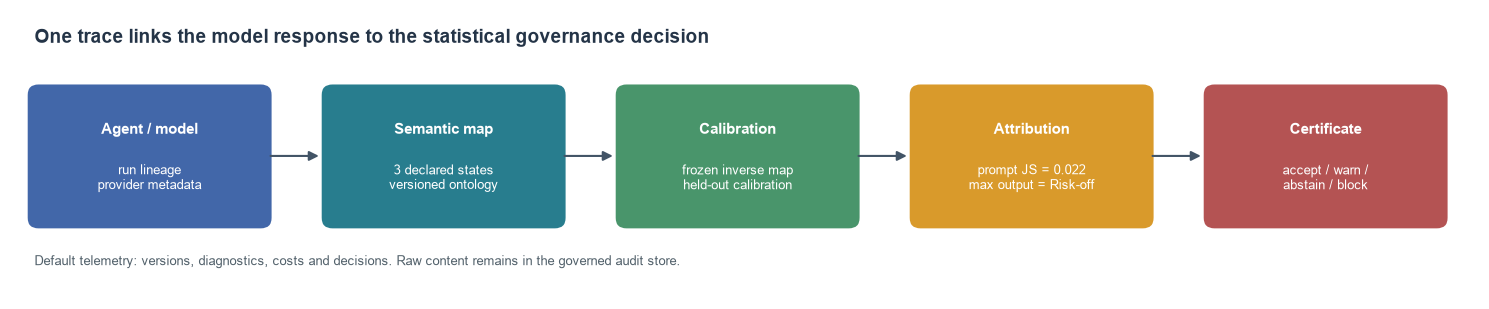

In [13]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def visualize_belieflens_trace(attribution):
    prompt = attribution['rankings']['prompt_spans'][0]
    output = attribution['rankings']['output_candidates'][0]
    stages = [
        ('Agent / model', 'run lineage\nprovider metadata', '#4267a9'),
        ('Semantic map', f"{len(attribution['ontology']['states'])} declared states\nversioned ontology", '#287d8e'),
        ('Calibration', 'frozen inverse map\nheld-out calibration', '#49956b'),
        ('Attribution', f"prompt JS = {prompt['mean_js_instability']:.3f}\nmax output = {output['candidate']}", '#d99a2b'),
        ('Certificate', 'accept / warn /\nabstain / block', '#b45353'),
    ]
    fig, ax = plt.subplots(figsize=(15, 3.2))
    ax.set_xlim(0, 15); ax.set_ylim(0, 3); ax.axis('off')
    for i, (title, detail, color) in enumerate(stages):
        x = .25 + i * 3.0
        box = FancyBboxPatch((x, .8), 2.35, 1.35, boxstyle='round,pad=.08,rounding_size=.12',
                             facecolor=color, edgecolor='white', linewidth=1.5)
        ax.add_patch(box)
        ax.text(x + 1.175, 1.75, title, color='white', weight='bold', ha='center', va='center', fontsize=10.5)
        ax.text(x + 1.175, 1.25, detail, color='white', ha='center', va='center', fontsize=9)
        if i < len(stages) - 1:
            ax.add_patch(FancyArrowPatch((x + 2.38, 1.48), (x + 2.93, 1.48), arrowstyle='-|>',
                                         mutation_scale=14, linewidth=1.5, color='#425466'))
    ax.text(.25, 2.65, 'One trace links the model response to the statistical governance decision',
            fontsize=14, weight='bold', color='#243447')
    ax.text(.25, .35, 'Default telemetry: versions, diagnostics, costs and decisions. Raw content remains in the governed audit store.',
            fontsize=9.5, color='#52616b')
    fig.tight_layout()
    return fig

trace_figure = visualize_belieflens_trace(attribution)
trace_figure;


In [14]:
trace_preview = pd.DataFrame([
    {'span': 'agent/model', 'parent': 'workflow', 'observable result': 'model, usage, latency and provider metadata', 'raw content exported by default': False},
    {'span': 'semantic_map.apply', 'parent': 'workflow', 'observable result': 'ontology and semantic-map versions', 'raw content exported by default': False},
    {'span': 'calibration.apply', 'parent': 'workflow', 'observable result': 'calibrator, partition and coverage diagnostics', 'raw content exported by default': False},
    {'span': 'attribution.analyze', 'parent': 'workflow', 'observable result': 'prompt JS, output sensitivity and top-k completeness', 'raw content exported by default': False},
    {'span': 'certificate.evaluate', 'parent': 'workflow', 'observable result': 'accept, warn, abstain or block', 'raw content exported by default': False},
])
trace_preview


,span,parent,observable result,raw content exported by default
0,agent/model,workflow,"model, usage, latency and provider metadata",False
1,semantic_map.apply,workflow,ontology and semantic-map versions,False
2,calibration.apply,workflow,"calibrator, partition and coverage diagnostics",False
3,attribution.analyze,workflow,"prompt JS, output sensitivity and top-k completeness",False
4,certificate.evaluate,workflow,"accept, warn, abstain or block",False


In [15]:
langchain_integration_preview = pd.DataFrame([
    ('BeliefLensMeasurementRunnable', 'calls one frozen measurement profile without refitting it', 'calibrated state probabilities inside the chain'),
    ('Measurement profile', 'binds benchmark, ontology, prompt, model, JSON calibrator, and certificate', 'prevents incompatible assets being mixed'),
    ('Conditional graph edge', 'routes on the returned certificate decision', 'continue, review, abstain, or block'),
    ('OpenTelemetry context', 'joins agent, model, semantic map, calibration, and action spans', 'one trace across vendor tools'),
], columns=['integration component', 'what it does', 'practical gain'])
langchain_integration_preview


,integration component,what it does,practical gain
0,BeliefLensMeasurementRunnable,calls one frozen measurement profile without refitting it,calibrated state probabilities inside the chain
1,Measurement profile,"binds benchmark, ontology, prompt, model, JSON calibrator, and certificate",prevents incompatible assets being mixed
2,Conditional graph edge,routes on the returned certificate decision,"continue, review, abstain, or block"
3,OpenTelemetry context,"joins agent, model, semantic map, calibration, and action spans",one trace across vendor tools
